# 第058讲 决策树的分裂机制

真实执行：手算候选、从零浅树、逐节点审计、库对照和边界。全部数据为原创合成材料。先重启内核，再依序运行；不要用测试分数调参。

In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
ROOT = Path.cwd()
if not (ROOT / 'tree.py').exists():
    ROOT = ROOT / 'units' / '058'
if not (ROOT / 'tree.py').exists():
    raise RuntimeError('请在 units/058 或课程仓库根目录启动')
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
from tree import ShallowTree, candidates, impurity
from experiment import run, load
from common import write_json
print('NumPy', np.__version__, '; lesson 058 ready')

NumPy 2.3.5 ; lesson 058 ready


## 1 手算以后再看候选
输入1至6，分类标签0、0、1、0、1、1。先预测：为什么2.5与4.5平局？回归标签换成1、2、2、8、9、8时，最佳阈值是否相同？

In [2]:
X = np.arange(1, 7)[:, None]
for name, target in [('gini', [0,0,1,0,1,1]), ('entropy', [0,0,1,0,1,1]), ('squared_error', [1,2,2,8,9,8])]:
    print(name, 'parent impurity =', impurity(target, name))
    for row in candidates(X, target, name):
        print('  t=%.1f weighted=%.6f gain=%.6f' % (row['threshold'], row['weighted_impurity'], row['gain']))

gini parent impurity = 0.5
  t=1.5 weighted=0.400000 gain=0.100000
  t=2.5 weighted=0.250000 gain=0.250000
  t=3.5 weighted=0.444444 gain=0.055556
  t=4.5 weighted=0.250000 gain=0.250000
  t=5.5 weighted=0.400000 gain=0.100000
entropy parent impurity = 1.0
  t=1.5 weighted=0.809125 gain=0.190875
  t=2.5 weighted=0.540852 gain=0.459148
  t=3.5 weighted=0.918296 gain=0.081704
  t=4.5 weighted=0.540852 gain=0.459148
  t=5.5 weighted=0.809125 gain=0.190875
squared_error parent impurity = 11.333333333333334
  t=1.5 weighted=8.133333 gain=3.200000
  t=2.5 weighted=5.208333 gain=6.125000
  t=3.5 weighted=0.222222 gain=11.111111
  t=4.5 weighted=5.208333 gain=6.125000
  t=5.5 weighted=9.533333 gain=1.800000


## 2 固定协议，再计算测试
深度2、最小叶样本12在代码中预先固定。run先完成全部训练及协议摘要，再读取测试CSV；两种分类准则都报告，不在测试上选赢家。

In [3]:
result = run()
write_json(ROOT / 'outputs/notebook/result.json', result)
for name, item in result['test'].items():
    keep = ['accuracy', 'baseline_accuracy', 'mse', 'baseline_mse', 'max_prediction_difference']
    print(name, {k: item[k] for k in keep if k in item})
print('Frozen state SHA-256:', result['frozen_sha256_before_test_read'])

gini {'accuracy': 0.76875, 'baseline_accuracy': 0.64375, 'max_prediction_difference': 0.0}
entropy {'accuracy': 0.76875, 'baseline_accuracy': 0.64375, 'max_prediction_difference': 0.0}
squared_error {'mse': 0.1467553791261458, 'baseline_mse': 1.8318890789745623, 'max_prediction_difference': 1.1102230246251565e-15}
Frozen state SHA-256: e87e8f2a6e8d64910c4523fd686638eba0d86cac07c26304b327492cf5ed1436


## 3 逐叶追踪统计量
正类概率必须能够写成“正类数 / 叶样本数”。如果只看到一个0.90，要继续问：这个比例来自多少训练样本？

In [4]:
for node in result['models']['gini']['nodes']:
    if node['feature'] is None:
        print('leaf', node['id'], 'n=', node['n'], 'positive=', round(node['n']*node['value']), 'p=', node['value'])
train_X, train_y = load('classification_train')
model = ShallowTree('gini', 2, 12).fit(train_X, train_y)
queries = np.array([[1, 1], [-1, 1]])
print('query leaf IDs:', model.apply(queries))
print('query probabilities:', model.predict_proba(queries))

leaf 2 n= 45 positive= 1 p= 0.022222222222222223
leaf 3 n= 115 positive= 14 p= 0.12173913043478261
leaf 5 n= 87 positive= 23 p= 0.26436781609195403
leaf 6 n= 73 positive= 66 p= 0.9041095890410958
query leaf IDs: [6 3]
query probabilities: [[0.09589041 0.90410959]
 [0.87826087 0.12173913]]


## 4 阈值等号的精确测试
在float64实现里，用相邻可表示浮点数检查阈值；不要混入库的float32转换语义。预期类别0、0、1。

In [5]:
boundary = ShallowTree('gini', 1).fit([[0], [2]], [0, 1])
t = boundary.nodes_[0]['threshold']
q = np.array([[np.nextafter(t, -np.inf)], [t], [np.nextafter(t, np.inf)]])
for value, pred in zip(q[:, 0], boundary.predict(q)):
    print(format(value, '.17g'), '->', pred)
if not np.array_equal(boundary.predict(q), [0,0,1]):
    raise RuntimeError('boundary check failed')

0.99999999999999989 -> 0
1 -> 0
1.0000000000000002 -> 1


## 5 XOR：能表示与能学到不同
严格正收益的本实现会停在根。自己写两层条件判断却可以全部预测正确。这个反例不等于所有树库都无法拟合XOR。

In [6]:
xor_X = np.array([[0,0], [0,1], [1,0], [1,1]])
xor_y = np.array([0,1,1,0])
xor = ShallowTree('gini', 2).fit(xor_X, xor_y)
print('root gains:', [r['gain'] for r in candidates(xor_X, xor_y)])
print('greedy predictions:', xor.predict(xor_X))
print('constructed depth-2 predictions:', (xor_X[:,0] != xor_X[:,1]).astype(int))

root gains: [0.0, 0.0]
greedy predictions: [0 0 0 0]
constructed depth-2 predictions: [0 1 1 0]


## 6 独立审计
检查器直接重算候选、节点分组、叶统计量与测试预测，还检验输入拒绝和边界，不只是读一个预存的passed标记。

In [7]:
from test_experiment import main as audit
check = audit(ROOT / 'outputs/notebook/result.json')
print({k:v for k,v in check.items() if k != 'check_names'})

{'status': 'passed', 'checks': 284, 'optimized_python': False, 'report': 'result.json'}


## 7 本次运行重绘六幅图
图像从当前结果重建，再嵌入Notebook。图中的英文标签与正文中文图注一一对应；左侧已知真实机制只在合成实验中可用。

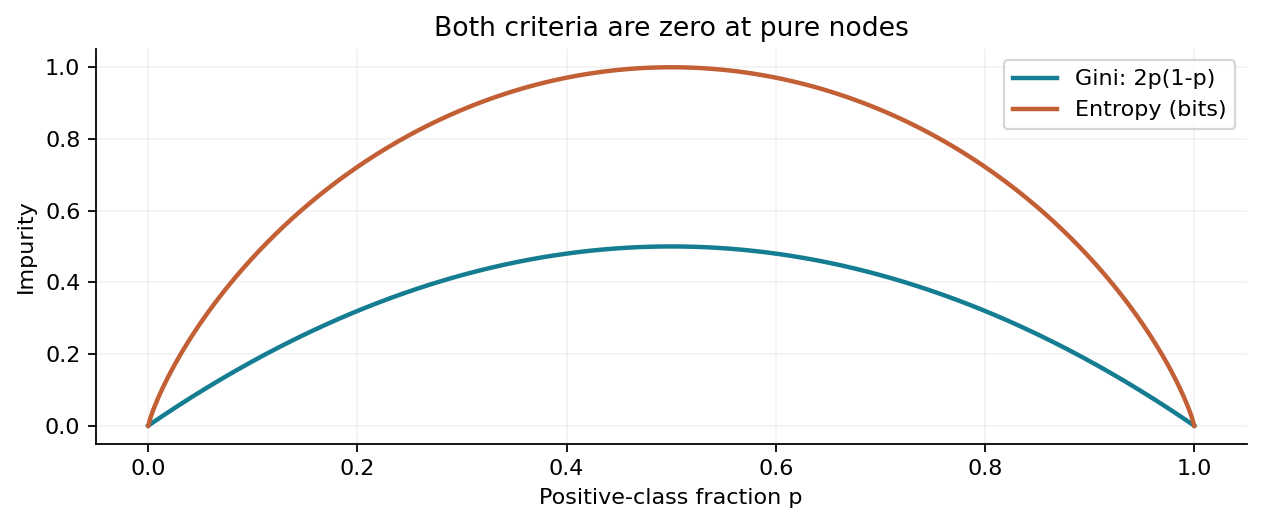

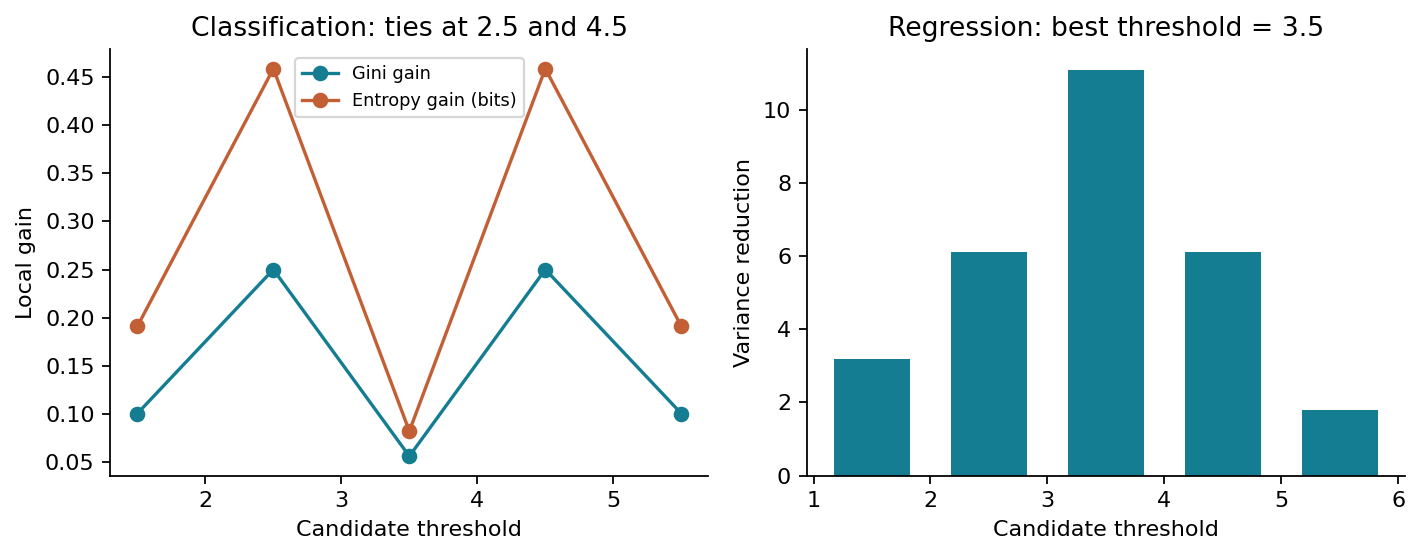

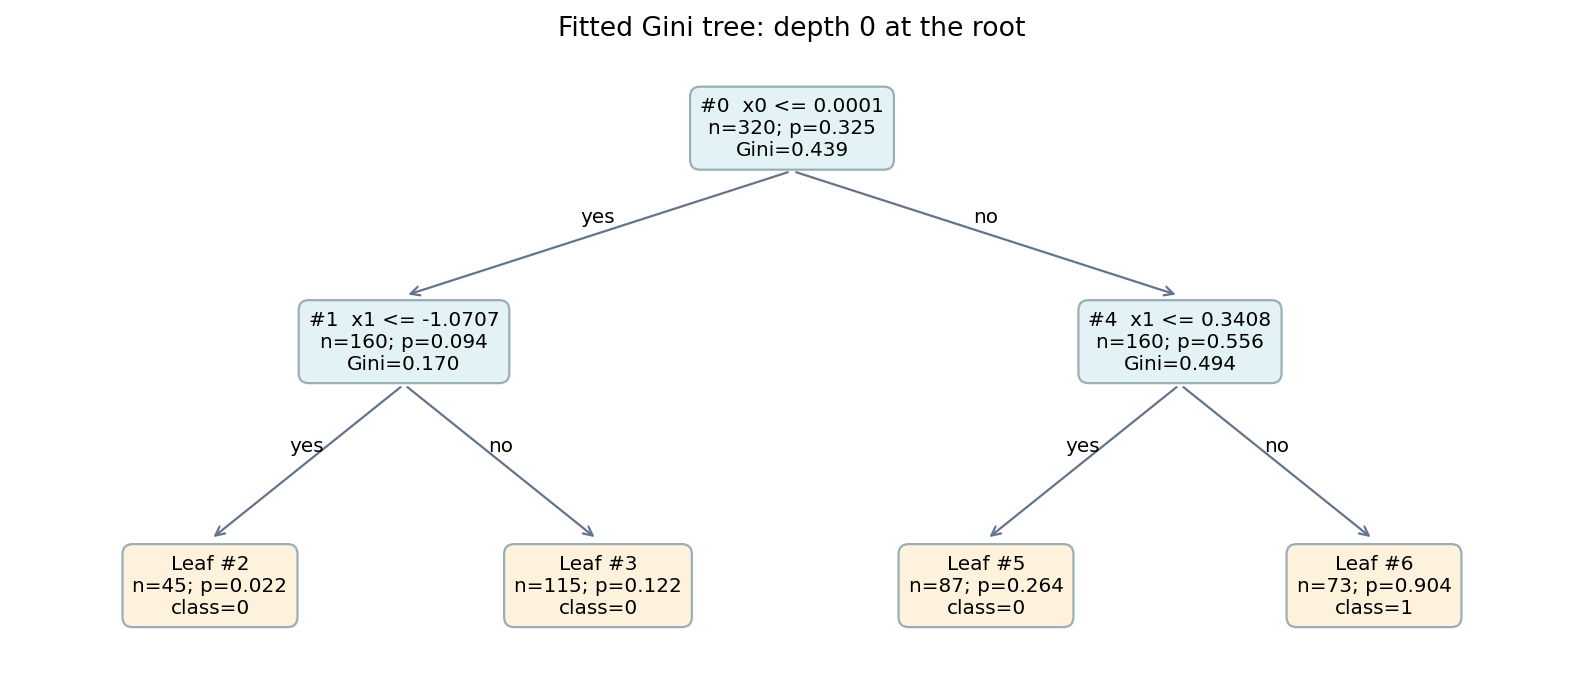

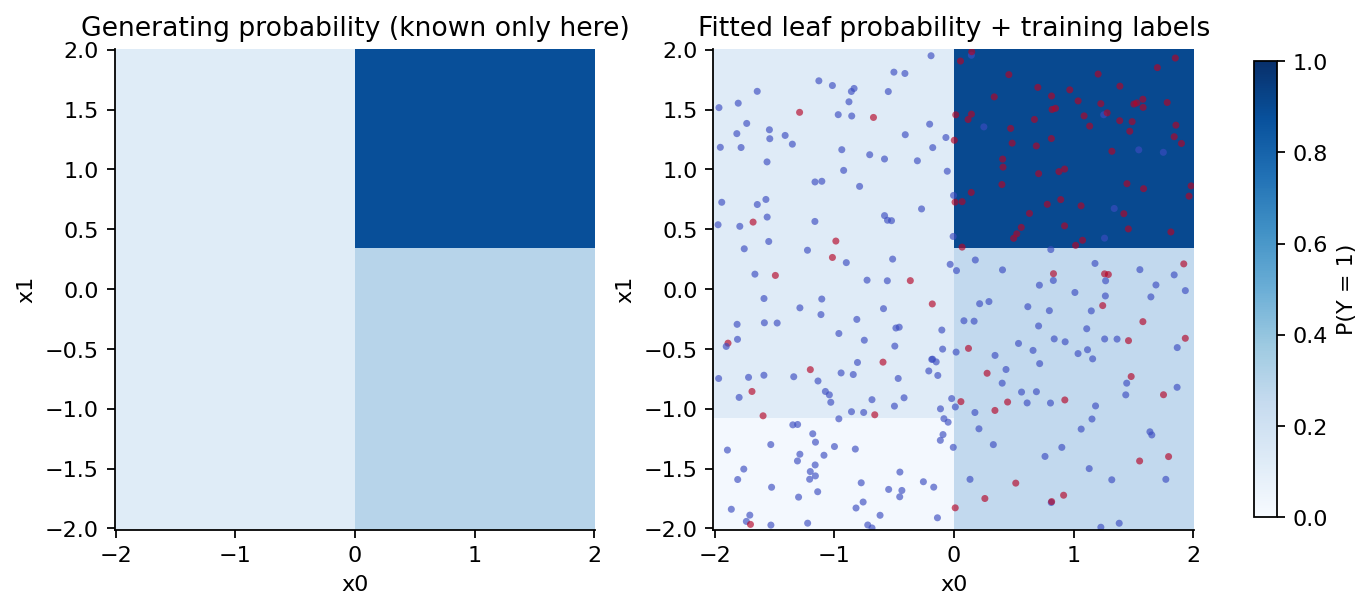

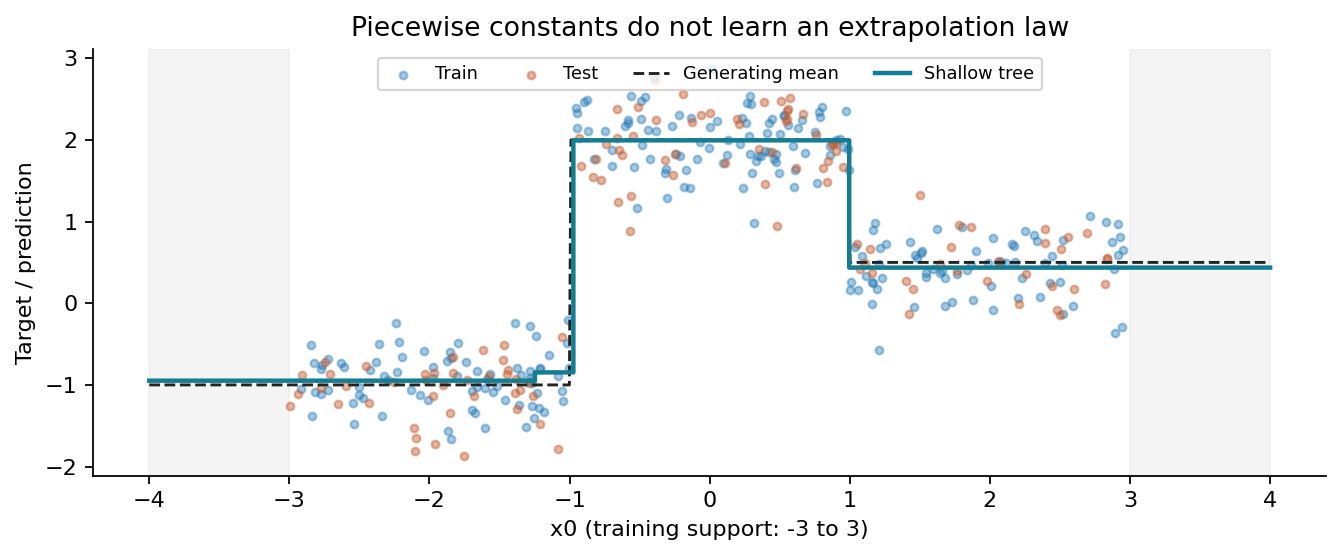

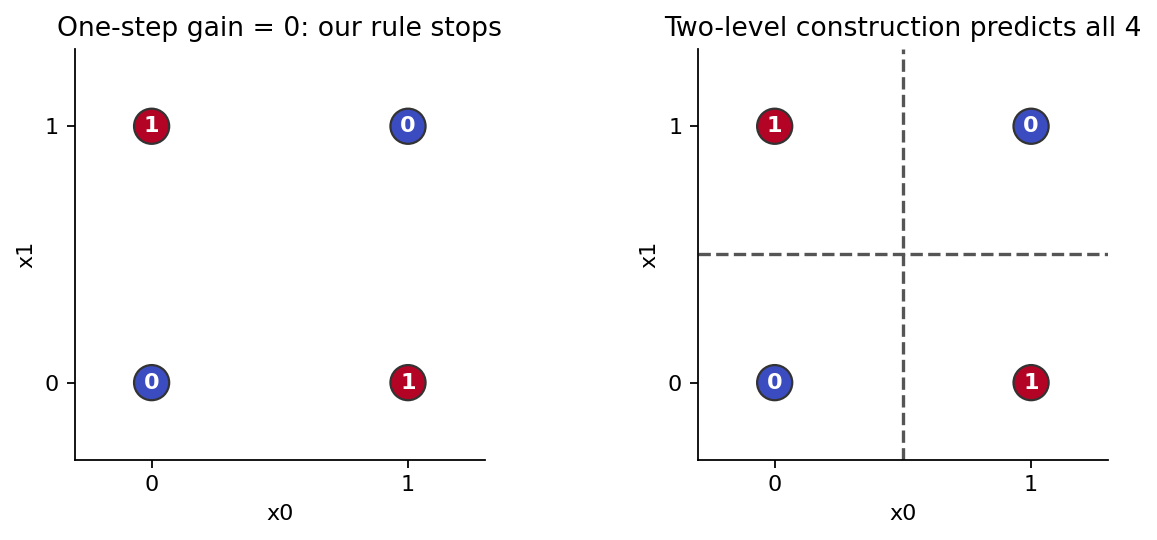

In [8]:
from plots import build
from IPython.display import display, Image
figure_paths = build(ROOT / 'outputs/notebook/result.json', ROOT / 'outputs/notebook/figures')
for path in figure_paths:
    display(Image(filename=str(path)))

## 8 带走的结论
训练损失必须按行数加权；分裂与叶值都属于训练结果；局部最好不保证全局最好；可读路径不证明因果。测试分数只属于本次合成总体。继续完成lab.md的12题，独立答案在answers.md。